In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping

In [5]:
data = yf.download('ETH-USD','2015-01-01','2026-04-28')

[*********************100%***********************]  1 of 1 completed


In [7]:
data = pd.DataFrame(data)

In [9]:
data

Price,Close,High,Low,Open,Volume
Ticker,ETH-USD,ETH-USD,ETH-USD,ETH-USD,ETH-USD
Date,,,,,
2017-11-09,320.884003,329.451996,307.056000,308.644989,893249984
2017-11-10,299.252991,324.717987,294.541992,320.670990,885985984
2017-11-11,314.681000,319.453003,298.191986,298.585999,842300992
2017-11-12,307.907990,319.153015,298.513000,314.690002,1613479936
2017-11-13,316.716003,328.415009,307.024994,307.024994,1041889984
...,...,...,...,...,...
2026-04-23,2331.513916,2380.135986,2287.553223,2376.087891,19909161913
2026-04-24,2315.690186,2337.266602,2301.527344,2331.568848,13371168064


In [11]:
len(data)

3092

In [13]:
data.reset_index(inplace= True)

In [15]:
data.drop(columns = ['Date','Open','High','Low','Volume'],inplace = True)

C:\Users\Laraib\AppData\Local\Temp\ipykernel_20008\2051505622.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  data.drop(columns = ['Date','Open','High','Low','Volume'],inplace = True)


In [17]:
data

Price,Close
Ticker,ETH-USD
0,320.884003
1,299.252991
2,314.681000
3,307.907990
4,316.716003
...,...
3087,2331.513916
3088,2315.690186
3089,2318.829102


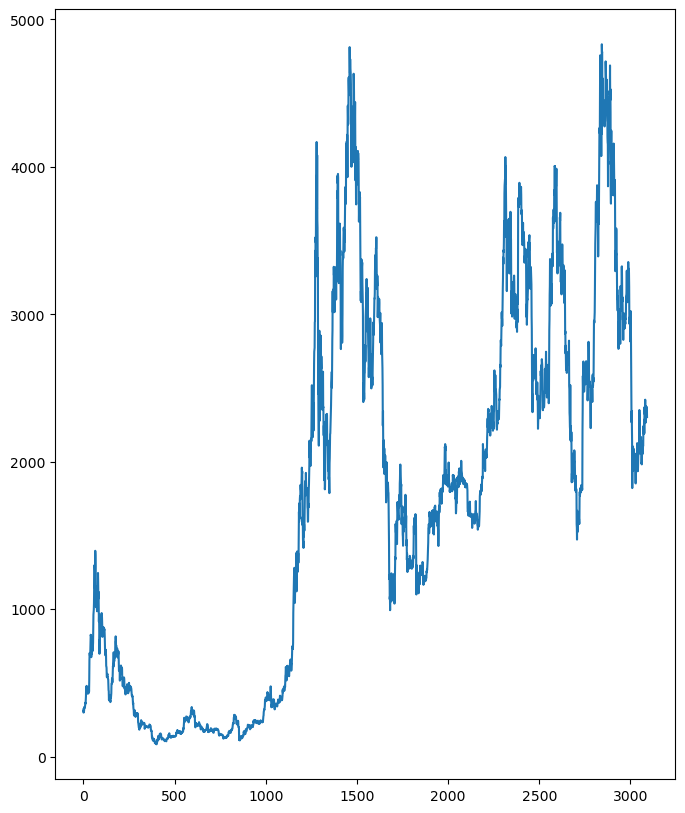

In [19]:
plt.figure(figsize=(8,10))
plt.plot(data)
plt.show()

In [21]:
train_data = data[:-100]
test_data = data[-100:]

In [23]:
train_data.shape

(2992, 1)

In [25]:
test_data.shape

(100, 1)

In [27]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range = (0,1))

In [28]:
train_data_scale = scaler.fit_transform(train_data)

In [31]:
base_days = 100

In [33]:
x = []
y = []
for i in range(base_days, train_data_scale.shape[0]):
    x.append(train_data_scale[i-base_days:i])
    y.append(train_data_scale[i,0])

In [35]:
x[0]

array([[0.04983646],
       [0.04527973],
       [0.04852975],
       [0.04710297],
       [0.04895844],
       [0.05336435],
       [0.05246399],
       [0.05195147],
       [0.05226114],
       [0.05546692],
       [0.05689391],
       [0.05949427],
       [0.05816102],
       [0.06242705],
       [0.06864439],
       [0.08228342],
       [0.08046439],
       [0.08152905],
       [0.08343024],
       [0.08186021],
       [0.07230078],
       [0.07642777],
       [0.08052001],
       [0.07986886],
       [0.08037528],
       [0.08129185],
       [0.07983347],
       [0.07252513],
       [0.07375115],
       [0.0783062 ],
       [0.0819866 ],
       [0.07529169],
       [0.09075712],
       [0.1194687 ],
       [0.13028302],
       [0.12881872],
       [0.12642397],
       [0.12890151],
       [0.133908  ],
       [0.14963781],
       [0.15641635],
       [0.15478649],
       [0.15520296],
       [0.12440419],
       [0.13378414],
       [0.12846735],
       [0.14356855],
       [0.145

In [37]:
x,y = np.array(x), np.array(y)

In [39]:
x = np.reshape(x, (x.shape[0], x.shape[1],1))

In [41]:
from keras.layers import LSTM, Dense, Dropout
from keras.models import Sequential

In [43]:
model = Sequential()
model.add(LSTM(50, activation='relu', return_sequences=True, input_shape =(x.shape[1],1)))
model.add(Dropout(0.2))
model.add(LSTM(60,activation= 'relu', return_sequences=True))
model.add(Dropout(0.3))
model.add(LSTM(80,activation='relu', return_sequences=True))
model.add(Dropout(0.4))
model.add(LSTM(120,activation= 'relu'))
model.add(Dropout(0.5))

model.add(Dense(units=1))

C:\Users\Laraib\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [45]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 100, 50)             │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 100, 50)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 100, 60)             │          26,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 100, 60)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 100, 80)             │          45,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 100, 80)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 120)                 │          96,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 120)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             121 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 178,761 (698.29 KB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

In [47]:
model.compile(optimizer = 'adam', loss = 'mean_squared_error')

In [51]:
early_stop = EarlyStopping(
    monitor='loss',          
    patience=5,              
    restore_best_weights=True
)

In [55]:
model.fit(x, y, epochs=50, verbose=1, callbacks=[early_stop])

Epoch 1/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 18s 192ms/step - loss: 0.0027
Epoch 2/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 22s 208ms/step - loss: 0.0027
Epoch 3/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 17s 188ms/step - loss: 0.0025
Epoch 4/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 18s 197ms/step - loss: 0.0025
Epoch 5/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 18s 196ms/step - loss: 0.0026


In [57]:
test_data

Price,Close
Ticker,ETH-USD
2992,3281.157715
2993,3186.621094
2994,2935.605713
2995,2978.901123
2996,2949.633301
...,...
3087,2331.513916
3088,2315.690186
3089,2318.829102


In [59]:
test_data = pd.concat((train_data.tail(100), test_data),ignore_index=True)

In [61]:
test_data

Price,Close
Ticker,ETH-USD
0,3843.008789
1,3750.611572
2,4164.427734
3,4245.467773
4,4125.412109
...,...
195,2331.513916
196,2315.690186
197,2318.829102


In [63]:
test_data_scale= scaler.transform(test_data)

In [65]:
x = []
y = []
for i in range(base_days, test_data_scale.shape[0]):
    x.append(test_data_scale[i-base_days:i])
    y.append(test_data_scale[i,0])

In [67]:
x,y = np.array(x), np.array(y)

In [69]:
x = np.reshape(x, (x.shape[0], x.shape[1],1))

In [71]:
pred = model.predict(x)

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 439ms/step


In [73]:
pred = scaler.inverse_transform(pred)

In [75]:
pred

array([[3346.5356],
       [3301.7222],
       [3227.9656],
       [3097.0461],
       [2972.2083],
       [2894.5261],
       [2880.3738],
       [2909.082 ],
       [2919.0435],
       [2926.2578],
       [2959.5935],
       [3003.7483],
       [2985.5803],
       [2892.645 ],
       [2750.151 ],
       [2579.749 ],
       [2416.653 ],
       [2283.294 ],
       [2187.7952],
       [2099.1318],
       [2027.5952],
       [1992.4482],
       [2000.2703],
       [2041.6906],
       [2078.273 ],
       [2080.477 ],
       [2051.3499],
       [2012.6028],
       [1989.6692],
       [1975.5018],
       [1966.3359],
       [1959.323 ],
       [1948.7982],
       [1932.7474],
       [1916.7776],
       [1907.2826],
       [1904.1267],
       [1893.0594],
       [1870.656 ],
       [1865.6488],
       [1892.4349],
       [1923.9672],
       [1945.3511],
       [1949.3491],
       [1948.1768],
       [1944.64  ],
       [1962.8518],
       [1996.6024],
       [2014.7261],
       [2007.5631],


In [77]:
m = y
z = []

future_days = 30

for i in range(base_days, len(m) + future_days):
    m = m.reshape(-1, 1)

    inter = m[-base_days:]   # ✅ FIX: use m instead of inter
    inter = np.array([inter])
    inter = inter.reshape(inter.shape[0], inter.shape[1], 1)

    pred = model.predict(inter)
    m= np.append(m,pred)
    z = np.append(z, pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━

In [78]:
z = np.array(z)
z = scaler.inverse_transform(z.reshape(-1,1))

In [81]:
z

array([[2328.53673132],
       [2319.52533669],
       [2309.48614197],
       [2299.89018162],
       [2290.73094789],
       [2281.67074514],
       [2272.45860057],
       [2262.99321964],
       [2253.25338142],
       [2243.21220609],
       [2232.84295527],
       [2222.17519679],
       [2211.20539382],
       [2199.96707543],
       [2188.46674936],
       [2176.5530397 ],
       [2164.1308767 ],
       [2151.13419254],
       [2137.40241559],
       [2122.89890436],
       [2107.53537982],
       [2091.16626643],
       [2073.88139943],
       [2055.69718968],
       [2036.7061604 ],
       [2016.86445501],
       [1996.19569947],
       [1974.62321552],
       [1952.22297407],
       [1929.32743625]])

In [85]:
model.save("Etherium_Price_Prediction_Model.keras")